# Shrink the Matrix \U0001F5DC
### An unbiased estimate can still be the wrong thing to give an optimiser

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Fragile](https://img.shields.io/badge/Usefulness-Fragile-dab617?style=flat-square)

Estimate a covariance matrix for forty stocks from one year of data and you are fitting 820
numbers to 252 observations. The result is not obviously broken — it is symmetric, it inverts,
the optimiser accepts it — and the portfolio it builds runs far more risk than it promised.
This notebook measures the damage and the fix.

> \U0001F4D3 **This is the plain-language layer.** The shrinkage algebra, the eigenvalue
> spectra and the paired tests are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Is the sample covariance matrix bad? | On eleven sectors, no. On forty names with a year of data, badly — and it does not look bad. |
| How does it fail? | It promises a quieter portfolio than it delivers, and concentrates the book in whatever looked calmest last year. |
| Does shrinkage fix it? | Substantially, with no tuning parameter and about three lines of algebra. |
| Is there a free alternative? | Yes: refuse to short. A long-only constraint is shrinkage in disguise (Jagannathan & Ma 2003). |

## 1 · The claim

> *"Just estimate the covariance matrix from the data. It's the unbiased estimator."*

It is. Unbiasedness is a statement about averages over many samples; it says nothing about
whether *this* matrix is a good thing to invert.

In [2]:
from shrinkage import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
sectors = [s for s in data.SECTORS if rets[s].notna().sum() > 1500]
names = [s for s in data.NAMES if rets[s].notna().sum() > 3000]
print(f"as-of {data.AS_OF}")
for tag, cols in (("sectors", sectors), ("names", names)):
    p = len(cols) * (len(cols) + 1) // 2
    print(f"  {tag:8s} {len(cols):3d} assets -> {p:4d} covariance parameters, "
          f"{252 / p:.2f} rows per parameter in a one-year window")

as-of 2026-06-30
  sectors   11 assets ->   66 covariance parameters, 3.82 rows per parameter in a one-year window
  names     40 assets ->  820 covariance parameters, 0.31 rows per parameter in a one-year window


## 2 · So what?

The inverse covariance matrix *is* the portfolio. Every optimiser — minimum variance, mean
variance, risk parity with a covariance term — multiplies by it. If the matrix has directions
where it wrongly believes there is almost no risk, the optimiser will find them and put money
there.

## 3 · The teardown

### 3.1 The promise and the delivery

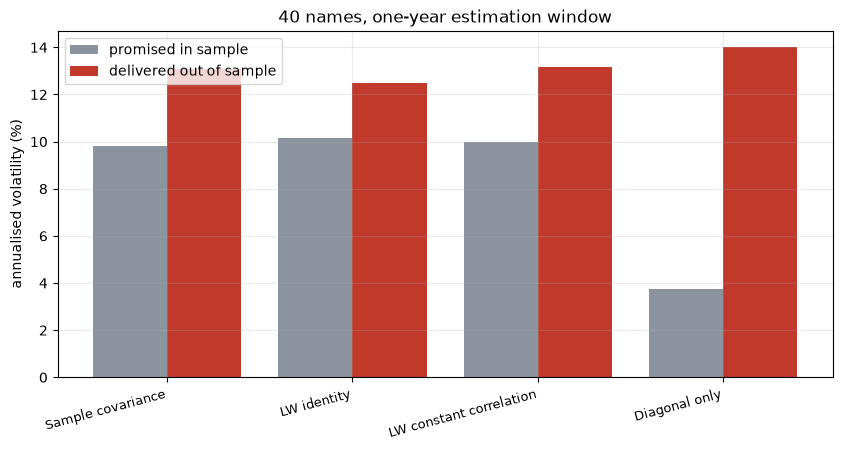

,delta,promised_vol,realised_vol,optimism,max_weight,condition
method,,,,,,
sample,0.0000,0.0981,0.1307,-0.2492,0.3163,334.6828
identity,0.0578,0.1017,0.1249,-0.1853,0.2415,162.4554
constant_corr,0.3846,0.1000,0.1318,-0.2415,0.2807,143.7027
diagonal,1.0000,0.0376,0.1400,-0.7314,0.0669,13.6253


In [3]:
sub = rets[names].dropna(how="any")
wf = st.walk_forward(sub, window=252, step=63, cost_bps=5.0)
s = st.summarise(wf)
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(s))
ax.bar(x - 0.2, s["promised_vol"] * 100, width=0.4, color="#8b949e", label="promised in sample")
ax.bar(x + 0.2, s["realised_vol"] * 100, width=0.4, color="#c0392b", label="delivered out of sample")
ax.set_xticks(x); ax.set_xticklabels([st.ESTIMATOR_LABEL[m].replace("Ledoit-Wolf -> ", "LW ")
                                      for m in s.index], rotation=15, ha="right", fontsize=9)
ax.set_ylabel("annualised volatility (%)"); ax.legend()
ax.set_title(f"{len(names)} names, one-year estimation window")
plt.show()
s[["delta", "promised_vol", "realised_vol", "optimism", "max_weight", "condition"]].round(4)

> \U0001F52C **For the quants.** The gap between the grey and the red bar for the sample matrix
> is not bad luck — it is the in-sample optimum of a noisy quadratic form, and its expected
> size grows with the number of assets.

### 3.2 The comfortable case, for contrast

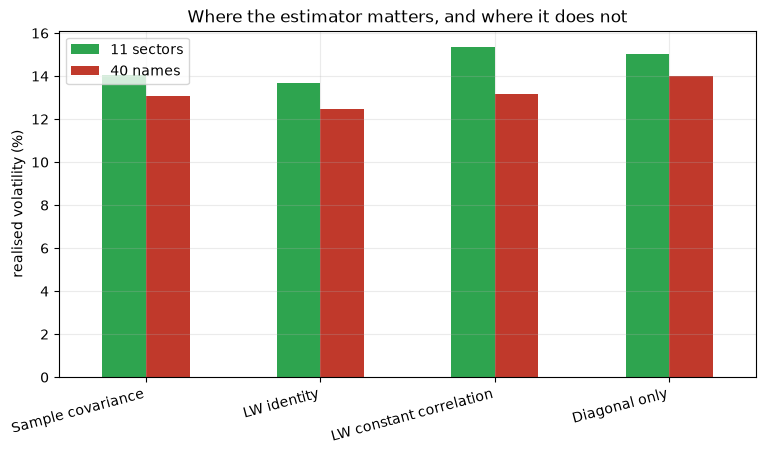

,11 sectors,40 names
Sample covariance,0.1404,0.1307
LW identity,0.1366,0.1249
LW constant correlation,0.1534,0.1318
Diagonal only,0.1503,0.1400


In [4]:
sec = rets[sectors].dropna(how="any")
s_sec = st.summarise(st.walk_forward(sec, window=252, step=63, cost_bps=5.0))
comp = pd.DataFrame({
    f"{len(sectors)} sectors": s_sec["realised_vol"],
    f"{len(names)} names": s["realised_vol"],
})
comp.index = [st.ESTIMATOR_LABEL[m].replace("Ledoit-Wolf -> ", "LW ") for m in comp.index]
fig, ax = plt.subplots(figsize=(9, 4.5))
(comp * 100).plot.bar(ax=ax, color=["#2ea44f", "#c0392b"])
ax.set_ylabel("realised volatility (%)")
ax.set_title("Where the estimator matters, and where it does not")
ax.legend(title="")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
plt.show()
comp.round(4)

### 3.3 What the sample matrix actually holds

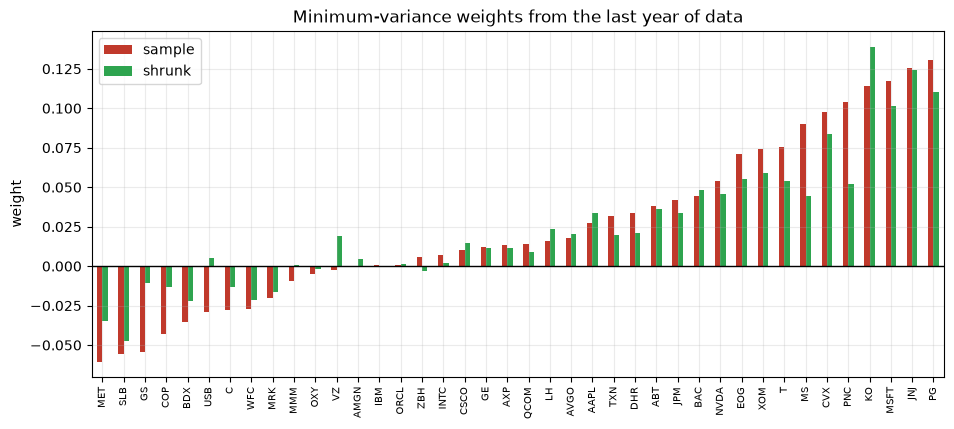

largest absolute weight: sample 13.1%, shrunk 13.9%
total short exposure   : sample 37.0%, shrunk 18.4%


In [5]:
last = sub.iloc[-252:].to_numpy()
w_sample = st.min_variance_weights(st.sample_cov(last))
w_shrunk = st.min_variance_weights(st.estimate(last, "constant_corr")[0])
d = pd.DataFrame({"sample": w_sample, "shrunk": w_shrunk}, index=names).sort_values("sample")
fig, ax = plt.subplots(figsize=(11, 4.5))
d.plot.bar(ax=ax, color=["#c0392b", "#2ea44f"])
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("weight"); ax.set_title("Minimum-variance weights from the last year of data")
ax.legend(title="")
plt.setp(ax.get_xticklabels(), fontsize=7)
plt.show()
print(f"largest absolute weight: sample {np.abs(w_sample).max():.1%}, "
      f"shrunk {np.abs(w_shrunk).max():.1%}")
print(f"total short exposure   : sample {np.clip(-w_sample, 0, None).sum():.1%}, "
      f"shrunk {np.clip(-w_shrunk, 0, None).sum():.1%}")

## 4 · The verdict

**Signal: Real.** On the wide cross-section (40 names, 820 covariance parameters, 252 rows of history) the sample matrix promises 9.81% annualised volatility and delivers **13.07%** — it is **25%** optimistic, and its median condition number is **335** against 162 for the shrunk version. On the eleven-sector sleeve, where rows outnumber parameters 4 to one, the same optimism is only 11% — the problem is arithmetic, not equities.

**Usefulness: Fragile.** **Ledoit-Wolf -> identity** cut realised volatility from 13.07% to **12.49%** — a **4%** saving, paired *t* = **+6.51** across 61 rebalances, winning 16% of them. It also turns over 1.14 against 1.54 per rebalance and holds a maximum weight of 24% against 32%. Three lines of algebra, no tuning parameter, no look-ahead.

## 5 · Going further \U0001F6AA

- **Nonlinear shrinkage** (Ledoit & Wolf 2017) treats each eigenvalue separately and beats the
  linear version tested here.
- **Random matrix theory**: clip every eigenvalue that falls inside the Marchenko-Pastur band
  and rebuild. Different derivation, similar answer.
- **1/N** remains the benchmark to beat, and often is not beaten (DeMiguel, Garlappi & Uppal
  2009) — see study 171 on this desk.